<a href="https://colab.research.google.com/github/PranavSrikarthik12/NeuralNetworks_CourseWork/blob/main/Ex1_XOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

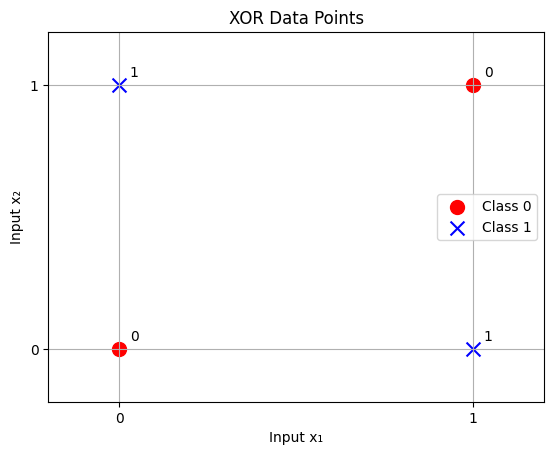

In [1]:
import matplotlib.pyplot as plt

x = [0, 0, 1, 1]
y = [0, 1, 0, 1]
labels = [0, 1, 1, 0]

for i in range(len(x)):
    if labels[i] == 0:
        plt.scatter(x[i], y[i], color='red', marker='o', s=100, label='Class 0' if i == 0 else "")
    else:
        plt.scatter(x[i], y[i], color='blue', marker='x', s=100, label='Class 1' if i == 1 else "")

    plt.text(x[i] + 0.03, y[i] + 0.03, str(labels[i]), fontsize=10)

plt.title("XOR Data Points")
plt.xlabel("Input x₁")
plt.ylabel("Input x₂")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.grid(True)
plt.legend()

plt.show()

Epoch [500/5000] Loss = 0.0028
Epoch [1000/5000] Loss = 0.0009
Epoch [1500/5000] Loss = 0.0005
Epoch [2000/5000] Loss = 0.0003
Epoch [2500/5000] Loss = 0.0002
Epoch [3000/5000] Loss = 0.0001
Epoch [3500/5000] Loss = 0.0001
Epoch [4000/5000] Loss = 0.0001
Epoch [4500/5000] Loss = 0.0000
Epoch [5000/5000] Loss = 0.0000


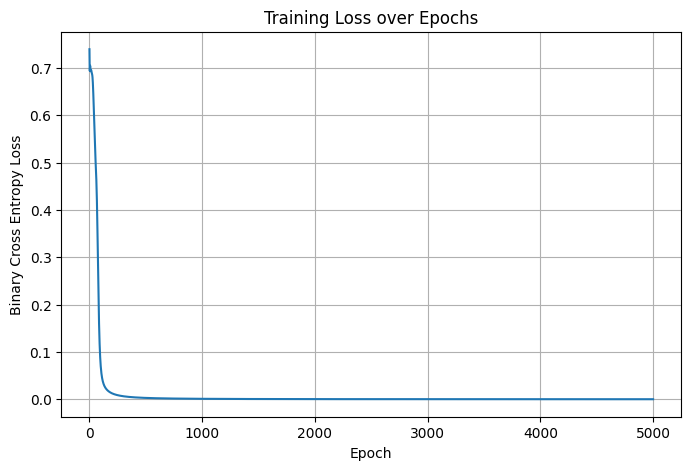


Predictions:
Input: [0.0, 0.0]  Predicted: 0  Actual: 0
Input: [0.0, 1.0]  Predicted: 1  Actual: 1
Input: [1.0, 0.0]  Predicted: 1  Actual: 1
Input: [1.0, 1.0]  Predicted: 0  Actual: 0

Final Prediction Accuracy: 100.00%


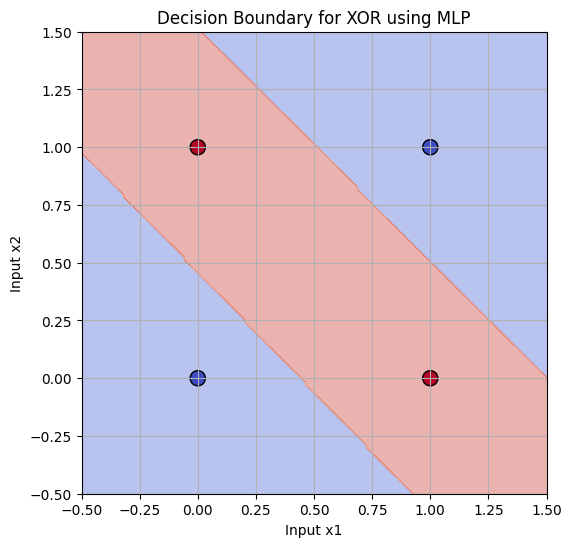

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

X = torch.tensor([[0., 0.],
                  [0., 1.],
                  [1., 0.],
                  [1., 1.]])

y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [0.]])

class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()

        self.hidden = nn.Linear(2, 2)
        self.output = nn.Linear(2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

model = XORNet()

criterion = nn.BCELoss()

optimizer = optim.Adam(model.parameters(), lr=0.1)

epochs = 5000
loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    outputs = model(X)
    loss = criterion(outputs, y)

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss = {loss.item():.4f}")

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.show()

with torch.no_grad():

    outputs = model(X)
    predicted = (outputs >= 0.5).float()

    accuracy = (predicted == y).sum().item() / len(y) * 100

    print("\nPredictions:")
    for i in range(len(X)):
        print(f"Input: {X[i].tolist()}  Predicted: {int(predicted[i].item())}  Actual: {int(y[i].item())}")

    print(f"\nFinal Prediction Accuracy: {accuracy:.2f}%")
import numpy as np

# Create a grid of points
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Convert grid to tensor
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid, dtype=torch.float32)

# Predict on every point in the grid
with torch.no_grad():
    Z = model(grid_tensor)
    Z = (Z >= 0.5).float().numpy()

# Reshape predictions to match the grid
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')

# Plot XOR data points
plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap='coolwarm',
            edgecolors='black', s=120)

plt.title("Decision Boundary for XOR using MLP")
plt.xlabel("Input x1")
plt.ylabel("Input x2")
plt.grid(True)
plt.show()